In [1]:
import numpy as np
import torch
from scipy.stats import gaussian_kde
from scipy.integrate import trapz
from scipy.stats import entropy
from scipy.optimize import minimize

In [3]:
from matplotlib import pyplot as plt

In [2]:
# from mTe_fun.py 

# Model Definition
n_grid = 300
x = np.linspace(0, 1, n_grid)

# Data
ic = np.nan
D = torch.load('dataExample.pt')

In [7]:
n =150

In [8]:
# from mTe_fun.py :21 - 29

# Determine regularization alpha depending on n
if n < 81:
    alpha = 0
elif n < 161:
    alpha = 1
elif n < 241:
    alpha = 10

options = {'alpha': alpha, 'Aug_matrix': [], 'x_combined': []}


# from mTe_fun.py :56 - 70
options['grid'] = x

# Compute mean u0 distribution
u0 = np.zeros((3, n_grid))
N01 = np.zeros(3)
for i0 in range(3):
    density = gaussian_kde(D['ind']['hist'][i0])
    u0[i0, :] = density(x)
    u0[i0, :] /= trapz(u0[i0, :], x)
    N01[i0] = len(D['ind']['hist'][i0])
    
options['u0'] = np.mean(u0, axis=0) * D['pop']['mean'][0]
options['u0'] = 0.5 * (options['u0'][:-1] + options['u0'][1:])

options['n_exp'] = 1

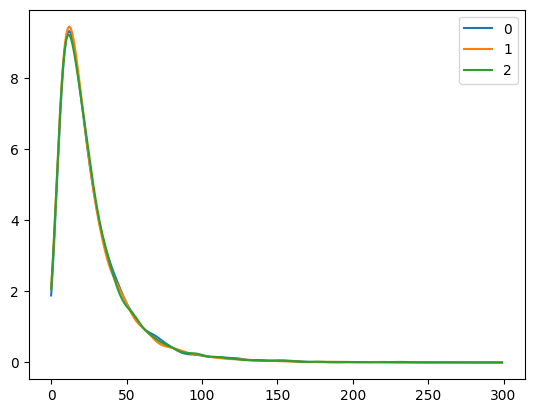

In [11]:
for i0 in range(3):
    plt.plot(u0[i0, :], label=str(i0))

plt.legend()

In [12]:
# from mTe_fun.py
x_combined = np.union1d(x[:-1], D['xsdt'][0])

In [14]:
x_combined.shape

(30298,)

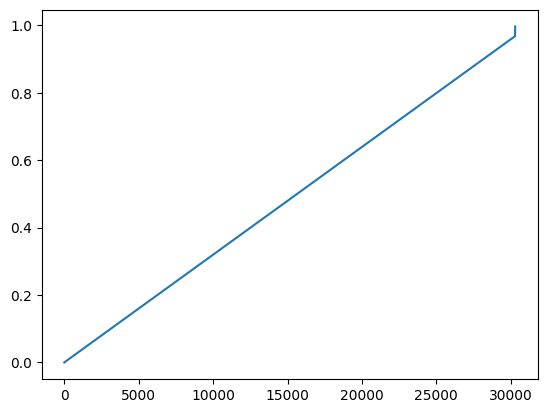

In [16]:
plt.plot(x_combined)